<a href="https://colab.research.google.com/github/Jack00027/Machine-Learning-in-Finance-Exercises/blob/main/Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training image number 11678 is supposed to be: 6


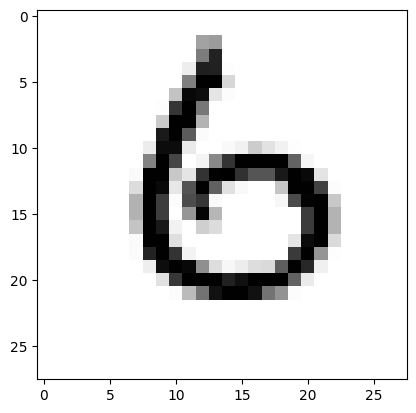

x_train shape: (60000, 28, 28, 1)
Number of images in x_train 60000
Number of images in x_test 10000


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8906 - loss: 0.3789
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9727 - loss: 0.0887
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9836 - loss: 0.0523
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9904 - loss: 0.0327
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9927 - loss: 0.0249
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9947 - loss: 0.0181
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9958 - loss: 0.0140
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9972 - loss: 0.0102
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9970 - loss: 0.0098
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9979 - loss: 0.0076
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - loss: 0.0815
Test result: [loss, accuracy]= [0.0689988434

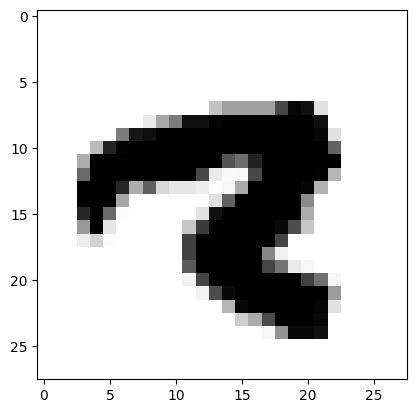

Prediction 8
Grand Truth 2


795010

In [ ]:
## Loading packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

## Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Function to display an image
def show(i, T=0):
    if T == 0:
        print("Training image number", i, "belongs to class:", y_train[i], "-", class_names[y_train[i]])
        plt.imshow(x_train[i], cmap='Greys')
        plt.show()
    else:
        print("Test image number", i, "belongs to class:", y_test[i], "-", class_names[y_test[i]])
        plt.imshow(x_test[i], cmap='Greys')
        plt.show()

## Show one random training image
image_index = np.random.randint(60000)
show(image_index)

## Reshape data to 4D tensors for Keras
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

## Convert to float
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

## Normalize pixel values to [0,1]
x_train /= 255
x_test /= 255

print("x_train shape:", x_train.shape)
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])
print("y_train shape:", y_train.shape)

## Import model/layers
from keras.models import Model
from keras.layers import Input, Dense, Flatten

## Define model
inputs = Input(shape=input_shape)
outputs = Flatten()(inputs)
outputs = Dense(1000, activation='relu')(outputs)
outputs = Dense(10, activation='softmax')(outputs)

model = Model(inputs=inputs, outputs=outputs)

## Summary
model.summary()

## Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train model
model.fit(x=x_train, y=y_train, epochs=10, batch_size=100)

## Evaluate on test set
results = model.evaluate(x_test, y_test)
print("Test result [loss, accuracy] =", results)

## Search for some wrongly classified images
img_rows = 28
img_cols = 28

for i in range(100):
    image_index = np.random.randint(10000)
    pred = model.predict(x_test[image_index].reshape(1, img_rows, img_cols, 1), verbose=0)
    predicted_class = pred.argmax()
    true_class = y_test[image_index]

    if predicted_class != true_class:
        print("Test image index:", image_index)
        plt.imshow(x_test[image_index].reshape(28, 28), cmap='Greys')
        plt.show()
        print("Prediction:", predicted_class, "-", class_names[predicted_class])
        print("Ground truth:", true_class, "-", class_names[true_class])

## Number of parameters
print("Total number of parameters:", model.count_params())